# Exercises week 38

**FYS-STK3155/4155, fall 2026 — deadline Friday September 18 at midnight.**

## Adaptive learning rates and stochastic gradient descent

The aim this week is that you extend last week's gradient descent code with
the adaptive methods AdaGrad, RMSProp and Adam, that you understand what each
of them does to the step and why their learning rate is not the learning rate
of plain gradient descent, and that you replace the full gradient by a
minibatch gradient with epochs and a learning-rate schedule. Everything here is
reused directly in parts f) and h) of Project 1. The code developed in the
Tuesday session (`week38tuesday.ipynb`, Cases 1 and 2) is meant to be reused,
and the Monday notebook (`week38.ipynb`) contains worked examples of every
piece.

After completing these exercises you will have

* derived the bias correction of Adam and the first step of the adaptive
  methods, and shown why they are insensitive to the scale of a feature;
* your own implementation of AdaGrad, RMSProp and Adam in the same
  three-function structure as last week's gradient descent, checked against
  the closed-form solutions of OLS and Ridge;
* scanned the learning rate for each method and related the windows you find
  to $2/\lambda_{\max}$ (Section 4.5) and to what $\gamma$ means for an
  adaptive method (Sections 4.8–4.12);
* a stochastic gradient descent loop with minibatches, epochs and the
  schedule of Eq. (4.40), and studied the batch size and the schedule
  (Section 4.7);
* applied all of it to the Runge function at degree 10, the problem nothing
  converged on last week.

Reading: Chapter 4, Sections 4.7–4.13 of the book; Goodfellow et al.,
Sections 8.1–8.5.

## The data

We keep last week's function,

$$
f(x) = 2 - x + 5x^2, \qquad x \in [-2, 2],
$$

with $n = 100$ points and Gaussian noise of standard deviation $0.5$, fitted
with polynomial features of degree 2 (an easy problem, $\kappa \approx 1.3$)
and degree 5 (a hard one, $\kappa \approx 520$). As last week, standardise the
columns of the design matrix, centre $\boldsymbol{y}$ and use no intercept
column; the closed-form OLS and Ridge solutions are your reference.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def exercise_data(n=100, degree=2, noise=0.5, seed=2026):
    """Standardised polynomial design matrix (no intercept column) and centred targets."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-2.0, 2.0, n)
    y = 2.0 - x + 5.0 * x**2 + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    return X_norm, y - y.mean()

def closed_form(X, y, lam=0.0):
    """(X^T X + n lambda I)^-1 X^T y, the 1/n convention of Eq. (3.95)."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)

def cost(theta, X, y, lam=0.0):
    """Eqs. (4.12) and (4.16)."""
    return np.sum((X @ theta - y) ** 2) / len(y) + lam * theta @ theta

def gradient(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): your analytical gradient from last week (or jax.grad of cost)."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta

def hessian_eigs(X, lam=0.0):
    n = len(X)
    return np.linalg.eigvalsh((2.0 / n) * X.T @ X + 2.0 * lam * np.eye(X.shape[1]))

X2, y2 = exercise_data(degree=2)
X5, y5 = exercise_data(degree=5)
for X in (X2, X5):
    eigs = hessian_eigs(X)
    print(f"degree {X.shape[1]}: kappa = {eigs.max() / eigs.min():.1f}, 2/lambda_max = {2 / eigs.max():.3f}")

degree 2: kappa = 1.3, 2/lambda_max = 0.894
degree 5: kappa = 520.3, 2/lambda_max = 0.354


## Exercise 1: what the adaptive methods do to the step (analytical)

The three adaptive methods replace the single learning rate $\gamma$ by a
per-coordinate step $\gamma/\sqrt{v_j}$, where $v_j$ estimates the second
moment of the gradient in coordinate $j$ (Section 4.8).

### 1a)

Unroll the RMSProp recursion of Eq. (4.47),
$\boldsymbol{v}_t = \rho\,\boldsymbol{v}_{t-1} + (1-\rho)\boldsymbol{g}_t^2$ with
$\boldsymbol{v}_0 = \boldsymbol{0}$, to obtain Eq. (4.49),
$\boldsymbol{v}_t = (1-\rho)\sum_{j=1}^{t}\rho^{\,t-j}\boldsymbol{g}_j^2$, and show
that the weights sum to $1 - \rho^t$. After how many steps has a gradient's
weight fallen below $1/e$ of its initial weight, for $\rho = 0.9$ and
$\rho = 0.99$? Compare with AdaGrad's sum, Eq. (4.42), whose weights are all
one.

### 1b)

Now Adam. Assume the gradient is stationary with $\mathbb{E}[g^2]$ constant.
Take the expectation of the unrolled second moment of Eq. (4.52) and derive
Eq. (4.53), $\mathbb{E}[v_t] = (1-\beta_2^{\,t})\,\mathbb{E}[g^2]$. Do the same
for the first moment with $\beta_1$. Explain why dividing by $1-\beta_i^t$,
Eq. (4.54), removes the bias exactly, and evaluate the correction factors at
$t = 1$, $t = 10$ and $t = 1000$ for the default $\beta_1 = 0.9$,
$\beta_2 = 0.999$.

### 1c)

Show that the first step of Adam, Eq. (4.55) at $t = 1$, is
$\Delta\theta_j = -\gamma\,\mathrm{sign}(g_{1,j})$ (up to $\epsilon$),
independent of the size of the gradient, and that the same holds for AdaGrad.
What is the first step of RMSProp, which has no bias correction, with
$\rho = 0.99$? What does this tell you about the meaning of $\gamma$ for these
methods, compared with plain gradient descent? Without bias correction, by
what factor would Adam's first step be too long?

### 1d)

Multiply one feature (one column of $\boldsymbol{X}$) by a constant $c$. Show
that the corresponding component of the gradient of the OLS cost scales by
$c$ and that the AdaGrad/RMSProp/Adam step in that coordinate is unchanged,
whereas the plain gradient descent step scales by $c$ (and the stability bound
$2/\lambda_{\max}$ moves). Why does this *not* mean that standardising the
data is unnecessary for the adaptive methods? (Hint: the Tuesday session's
rotated bowl.)

# Exercise 1

## 1a

From the assumption we know

$$
v_t=\rho v_{t-1}+(1-\rho)g_t^2,
\qquad v_0=0.
$$

For the first step,

$$
v_1=(1-\rho)g_1^2.
$$

For the second step,

$$
v_2=\rho v_1+(1-\rho)g_2^2
$$

so

$$
v_2=(1-\rho)(\rho g_1^2+g_2^2).
$$

For the third step,

$$
v_3=(1-\rho)(\rho^2 g_1^2+\rho g_2^2+g_3^2).
$$

Therefore,

$$
v_t=(1-\rho)\sum_{j=1}^{t}\rho^{t-j}g_j^2.
$$

The sum of the weights is

$$
(1-\rho)\sum_{k=0}^{t-1}\rho^k
=
(1-\rho)\frac{1-\rho^t}{1-\rho}
=
1-\rho^t.
$$

A gradient that is $k$ steps old has weight proportional to

$$
\rho^k.
$$

We want

$$
\rho^k<\frac{1}{e}.
$$

Taking the logarithm gives

$$
k>\frac{-1}{\ln(\rho)}.
$$

For $\rho=0.9$,

$$
k\approx 9.49,
$$

so the weight falls below $1/e$ after about **10 steps**.

For $\rho=0.99$,

$$
k\approx 99.5,
$$

so it takes about **100 steps**.

For AdaGrad,

$$
r_t=\sum_{j=1}^{t}g_j^2,
$$

so all previous gradients have weight $1$. Therefore, AdaGrad remembers all past gradients, while RMSProp gives smaller weights to older gradients.

## Exercise 1b

For Adam, the second moment is

$$
v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2,
$$

with

$$
v_0=0.
$$

Unrolling the recursion gives

$$
v_t=(1-\beta_2)
\sum_{j=1}^{t}\beta_2^{t-j}g_j^2.
$$

Assume the gradient is stationary, so

$$
E[g_j^2]=E[g^2].
$$

Taking the expectation,

$$
E[v_t]
=
(1-\beta_2)
\sum_{j=1}^{t}\beta_2^{t-j}E[g^2].
$$

Since $E[g^2]$ is constant,

$$
E[v_t]
=
(1-\beta_2)E[g^2]
\sum_{j=1}^{t}\beta_2^{t-j}.
$$

Using the geometric sum,

$$
\sum_{j=1}^{t}\beta_2^{t-j}
=
\frac{1-\beta_2^t}{1-\beta_2}.
$$

Therefore,

$$
E[v_t]
=
(1-\beta_2^t)E[g^2].
$$

For the first moment,

$$
m_t=\beta_1m_{t-1}+(1-\beta_1)g_t,
$$

with

$$
m_0=0.
$$

In the same way,

$$
E[m_t]
=
(1-\beta_1^t)E[g].
$$

Therefore, Adam uses the bias corrections

$$
\hat m_t=\frac{m_t}{1-\beta_1^t}
$$

and

$$
\hat v_t=\frac{v_t}{1-\beta_2^t}.
$$

Then

$$
E[\hat m_t]
=
\frac{E[m_t]}{1-\beta_1^t}
=
E[g],
$$

and

$$
E[\hat v_t]
=
\frac{E[v_t]}{1-\beta_2^t}
=
E[g^2].
$$

Thus dividing by $1-\beta_i^t$ removes the bias exactly.

For $\beta_1=0.9$ and $\beta_2=0.999$, the bias-correction factors are

$$
\frac{1}{1-\beta_1^t},
\qquad
\frac{1}{1-\beta_2^t}.
$$

At $t=1$,

$$
\frac{1}{1-0.9^1}=10,
\qquad
\frac{1}{1-0.999^1}=1000.
$$

At $t=10$,

$$
\frac{1}{1-0.9^{10}}\approx1.535,
\qquad
\frac{1}{1-0.999^{10}}\approx100.451.
$$

At $t=1000$,

$$
\frac{1}{1-0.9^{1000}}\approx1,
\qquad
\frac{1}{1-0.999^{1000}}\approx1.582.
$$

Thus, the bias correction is very important at the beginning, especially for the second moment, and becomes smaller as $t$ increases.

## Exercise 1c

For Adam at $t=1$,

$$
m_1=(1-\beta_1)g_1,
\qquad
v_1=(1-\beta_2)g_1^2.
$$

After bias correction,

$$
\hat m_1=\frac{m_1}{1-\beta_1}=g_1,
\qquad
\hat v_1=\frac{v_1}{1-\beta_2}=g_1^2.
$$

Therefore, the first Adam step is

$$
\Delta\theta_j
=
-\gamma
\frac{g_{1,j}}{\sqrt{g_{1,j}^2}+\epsilon}
\approx
-\gamma\,\mathrm{sign}(g_{1,j}).
$$

Thus, the first step is independent of the magnitude of the gradient.

For AdaGrad, after the first step,

$$
G_1=g_1^2,
$$

so

$$
\Delta\theta_j
=
-\gamma\frac{g_{1,j}}{\sqrt{g_{1,j}^2}+\epsilon}
\approx
-\gamma\,\mathrm{sign}(g_{1,j}).
$$

For RMSProp with $\rho=0.99$,

$$
v_1=(1-\rho)g_1^2=0.01g_1^2.
$$

Hence,

$$
\Delta\theta_j
=
-\gamma\frac{g_{1,j}}{\sqrt{0.01g_{1,j}^2}}
=
-10\gamma\,\mathrm{sign}(g_{1,j}).
$$

Therefore, in Adam and AdaGrad, $\gamma$ directly controls the approximate step size, while in plain gradient descent the step size also depends on the magnitude of the gradient.

Without bias correction, Adam's first step would be

$$
\Delta\theta_j
=
-\gamma
\frac{(1-\beta_1)g_{1,j}}
{\sqrt{(1-\beta_2)g_{1,j}^2}}.
$$

For $\beta_1=0.9$ and $\beta_2=0.999$,

$$
\frac{1-\beta_1}{\sqrt{1-\beta_2}}
=
\frac{0.1}{\sqrt{0.001}}
\approx 3.16.
$$

Thus, without bias correction, Adam's first step would be about $3.16$ times too large.

## Exercise 1d

For OLS,

$$
C(\theta)=\frac{1}{n}\|X\theta-y\|^2,
$$

and the gradient is

$$
\nabla C(\theta)=\frac{2}{n}X^T(X\theta-y).
$$

If one feature column $X_j$ is multiplied by a constant $c$, while the corresponding parameter is rescaled so that the prediction is unchanged, then the corresponding gradient component becomes

$$
g_j' = c g_j.
$$

For plain gradient descent,

$$
\Delta \theta_j=-\gamma g_j,
$$

so after rescaling,

$$
\Delta \theta_j'=-\gamma c g_j.
$$

Thus the GD step scales by $c$. The Hessian also changes, so $\lambda_{\max}$ changes and therefore the stability bound

$$
\gamma < \frac{2}{\lambda_{\max}}
$$

also changes.

For AdaGrad, RMSProp and Adam, the squared-gradient accumulator scales as $c^2$. Therefore,

$$
\frac{c g_j}{\sqrt{c^2 v_j}}
=
\frac{g_j}{\sqrt{v_j}}
$$

for $c>0$.

Hence the adaptive step in that coordinate is approximately unchanged.

However, this does not mean that standardisation is unnecessary. Adaptive methods correct coordinate-wise scaling, but they do not remove correlations or rotations between features. A rotated, ill-conditioned loss surface can therefore still be difficult to optimise.

## Exercise 2: implementing AdaGrad, RMSProp and Adam

Extend last week's code with one step function that holds all five
optimisers. The template below has the update rules to fill in; keep the
gradient as an argument so that the analytical gradient and `jax.grad` are
interchangeable, as in part e) of Project 1.

In [2]:
def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    """One update of theta from the gradient g at step t = 1, 2, ...; state carries the running quantities."""
    if method == "plain":                                    # Eq. (4.10)
        return theta - gamma * g, state
    if method == "momentum":                                 # Eq. (4.28)
        state["v"] = v = beta * state.get("v", 0.0) + gamma * g
        return theta - v, state
    if method == "adagrad":                                  # Eqs. (4.42) and (4.45)
        state["r"] = r = state.get("r", 0.0) + g * g
        return theta - gamma * g / (np.sqrt(r) + eps), state
    if method == "rmsprop":                                  # Eqs. (4.47) and (4.48)
        state["r"] = r = rho * state.get("r", 0.0) + (1.0 - rho) * g * g
        return theta - gamma * g / (np.sqrt(r) + eps), state
    if method == "adam":                                     # Eqs. (4.51), (4.52), (4.54), (4.55)
        state["m"] = m =  beta1 * state.get("m", 0.0) + (1.0 - beta1) * g
        state["r"] = r =  beta2 * state.get("r", 0.0) + (1.0 - beta2) * g * g
        m_hat, r_hat =  m / (1.0 - beta1**t), r / (1.0 - beta2**t) 
        return theta - gamma * m_hat / (np.sqrt(r_hat) + eps), state
    raise ValueError(f"unknown method {method}")

def optimise(grad, theta0, method, gamma, num_iters=1000, tol=1e-8, **kw):
    """Full-gradient loop; returns all iterates and the number of steps taken."""
    theta, state = np.array(theta0, dtype=float), {}
    history = [theta.copy()]
    for t in range(1, num_iters + 1):
        g = grad(theta)
        theta, state = optimiser_step(method, theta, g, state, t, gamma, **kw)
        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(history), t

### 2a)

Run all five methods on the degree-2 data for OLS and for Ridge with
$\lambda = 0.01$ (remember the $n\lambda\boldsymbol{I}$ of the closed form).
Use $\gamma = 0.5$ for plain gradient descent and momentum and try
$\gamma \in \{0.01, 0.1\}$ for the adaptive methods. Do all of them converge to
the closed-form solution? Plot the distance
$\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\|$ against the iteration for
each method.

### 2b)

Repeat for the degree-5 data ($\kappa = 520$), with $\gamma = 0.9 \cdot 2/\lambda_{\max}$
for plain descent and momentum. Report the number of iterations to reach
$\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\| < 10^{-6}$ for each method,
and identify the method that does not get there at a constant $\gamma$.
Explain why, using your result from exercise 1c).

### 2c)

Check one method against a library implementation: for the degree-2 OLS
problem, run `optax.adam` (or `torch.optim.Adam`, or any other) with the same
$\gamma$, $\beta_1$, $\beta_2$ and $\epsilon$ from the same starting point, and
compare the first ten iterates with your own. They should agree to rounding.
If they do not, the usual suspects are the bias correction and the placement
of $\epsilon$ (inside or outside the square root).

X shape: (100, 2)
theta0 shape: (2,)
Closed form: [-1.0773505  5.854734 ]
Plain: [-1.0773505  5.854734 ]
Momentum: [-1.07735051  5.85473401]
AdaGrad gamma = 0.01
Final theta = [-0.41119223  0.60704681]
AdaGrad gamma = 0.1
Final theta = [-0.93211244  4.63872876]
RMSProp gamma = 0.01
Final theta = [-1.07535967  5.85473672]
RMSProp gamma = 0.1
Final theta = [-1.02946184  5.90262267]
Adam gamma =  0.01
Final theta =  [-1.03686219  5.51834276]
Adam gamma =  0.1
Final theta =  [-1.0773505  5.854734 ]


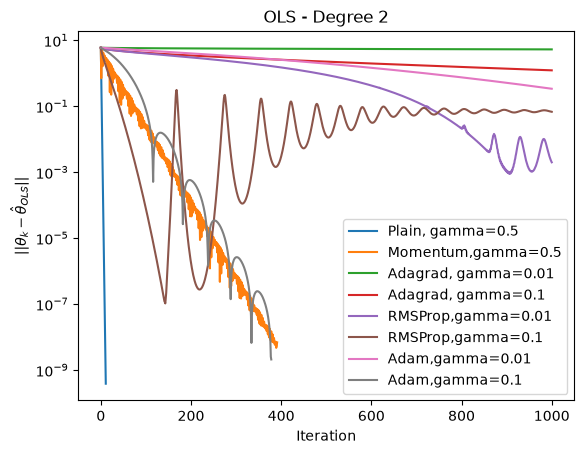

Ridge closed form: [-1.0596409   5.79468915]


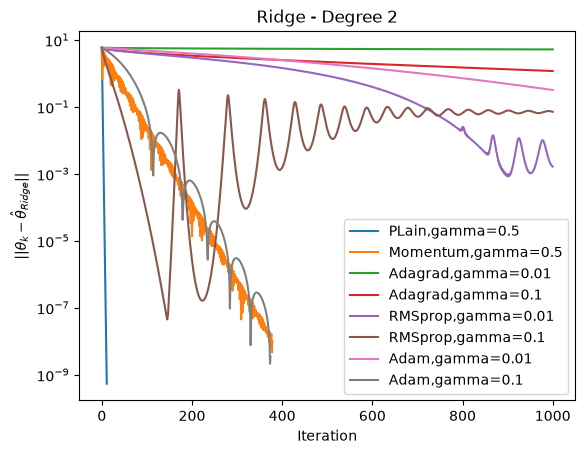

Ridge closed form: [-1.0596409   5.79468915]
Plain: [-1.0596409   5.79468915]
Momentum: [-1.05964089  5.79468915]
AdaGrad 0.01 [-0.40854111  0.60691748]
RMSProp 0.01 [-1.05798454  5.79469268]
Adam 0.01 [-1.02165685  5.47594954]
AdaGrad 0.1 [-0.92061015  4.61901713]
RMSProp 0.1 [-1.00895284  5.8453772 ]
Adam 0.1 [-1.0596409   5.79468914]


In [3]:
#Exercise 2a

import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import grad

#Degree 2 data
X = X2
y = y2

#OLS closed form
theta_OLS = closed_form(X, y, lam=0.0)

#OLS gradient
grad_OLS = lambda theta: gradient(theta, X, y, lam=0.0)

#Initial theta
theta0 = np.zeros(X.shape[1])

print("X shape:", X.shape)
print("theta0 shape:", theta0.shape)
print("Closed form:", theta_OLS)

#Plain
history_plain, steps_plain = optimise( grad_OLS, theta0, method="plain", gamma=0.5 )

#Momentum
history_momentum, steps_momentum = optimise( grad_OLS, theta0, method="momentum", gamma=0.5 )

print("Plain:", history_plain[-1])
print("Momentum:", history_momentum[-1])



#Different values of gamma
r = [0.01, 0.1]

# Save histories
adagrad_histories = {}
rmsprop_histories = {}
adam_histories = {}

#AdaGrad
for gamma in r:
    history_adagrad, steps = optimise( grad_OLS, theta0, method="adagrad", gamma=gamma )
    adagrad_histories[gamma] = history_adagrad
    print("AdaGrad gamma =", gamma)
    print("Final theta =", history_adagrad[-1])


#RMSProp
for gamma in r:
    history_RMS_PROP, steps = optimise( grad_OLS, theta0, method="rmsprop", gamma=gamma )
    rmsprop_histories[gamma] = history_RMS_PROP
    print("RMSProp gamma =", gamma)
    print("Final theta =", history_RMS_PROP[-1])

#Adam

for gamma in r: 
    history_adam,steps = optimise(grad_OLS,theta0,method="adam",gamma = gamma )
    adam_histories[gamma] = history_adam
    print("Adam gamma = ",gamma)
    print("Final theta = ",history_adam[-1])

distance_plain = np.linalg.norm(history_plain-theta_OLS,axis=1)
distance_momentum = np.linalg.norm(history_momentum-theta_OLS,axis = 1)

plt.plot(distance_plain,label="Plain, gamma=0.5")
plt.plot(distance_momentum,label="Momentum,gamma=0.5")

#Adapative

for gamma in r:

    distance = np.linalg.norm( adagrad_histories[gamma] - theta_OLS, axis=1 )

    plt.plot(distance,label= f"Adagrad, gamma={gamma}")


for gamma in r: 

    distance= np.linalg.norm(rmsprop_histories[gamma]-theta_OLS,axis=1)

    plt.plot(distance,label = f"RMSProp,gamma={gamma}")

for gamma in r: 

    distance = np.linalg.norm(adam_histories[gamma]-theta_OLS,axis=1)

    plt.plot(distance,label = f"Adam,gamma={gamma}")

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel(r"$||\theta_k-\hat{\theta}_{OLS}||$")
plt.title("OLS - Degree 2")
plt.legend()
plt.show()


# Ridge

lmbda = 0.01

# Ridge closed form
theta_Ridge = closed_form(X, y, lam=lmbda)

# Ridge gradient
grad_Ridge = lambda theta: gradient(theta, X, y, lam=lmbda)

print("Ridge closed form:", theta_Ridge)

history_plain_Ridge, steps_plain_Ridge = optimise( grad_Ridge, theta0, method="plain", gamma=0.5 )

history_momentum_Ridge, steps_momentum_Ridge = optimise( grad_Ridge, theta0, method="momentum", gamma=0.5 )


r = [0.01, 0.1]
adagrad_Ridge = {}
rmsprop_Ridge = {}
adam_Ridge = {}

# AdaGrad
for gamma in r:

    history, steps = optimise( grad_Ridge, theta0, method="adagrad", gamma=gamma )

    adagrad_Ridge[gamma] = history


# RMSProp
for gamma in r:

    history, steps = optimise(grad_Ridge,theta0,method="rmsprop",gamma=gamma)
    rmsprop_Ridge[gamma] = history


# Adam
for gamma in r:

    history, steps = optimise(grad_Ridge,theta0,method="adam",gamma=gamma)

    adam_Ridge[gamma] = history

#Distance

distance_plain_Ridge = np.linalg.norm(history_plain_Ridge-theta_Ridge,axis = 1)

distance_momentum_Ridge= np.linalg.norm(history_momentum_Ridge-theta_Ridge,axis=1)

plt.plot(distance_plain_Ridge,label="PLain,gamma=0.5")
plt.plot(distance_momentum_Ridge,label="Momentum,gamma=0.5")


for gamma in r: 

    distance = np.linalg.norm( adagrad_Ridge[gamma] - theta_Ridge, axis=1 )
    plt.plot(distance,label=f"Adagrad,gamma={gamma}")


for gamma in r:
    distance = np.linalg.norm(rmsprop_Ridge[gamma]-theta_Ridge,axis=1)
    plt.plot(distance,label=f"RMSprop,gamma={gamma}")

for gamma in r: 
    distance = np.linalg.norm(adam_Ridge[gamma]-theta_Ridge,axis=1)
    plt.plot(distance,label=f"Adam,gamma={gamma}")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel(r"$||\theta_k-\hat{\theta}_{Ridge}||$")
plt.title("Ridge - Degree 2")
plt.legend()
plt.show()
print("Ridge closed form:", theta_Ridge)

print("Plain:", history_plain_Ridge[-1])
print("Momentum:", history_momentum_Ridge[-1])

for gamma in r:
    print("AdaGrad", gamma, adagrad_Ridge[gamma][-1])
    print("RMSProp", gamma, rmsprop_Ridge[gamma][-1])
    print("Adam", gamma, adam_Ridge[gamma][-1])
#Conclusion
#For both OLS and Ridge, plain gradient descent and momentum converge very close to the closed-form solution.
#Plain gradient descent converges the fastest, while momentum takes more iterations to reach the optimum.
#AdaGrad converges more slowly, especially for small gamma, because its effective learning rate decreases over time.
#RMSProp with gamma=0.01 gets very close to the closed-form solution, while gamma=0.1 oscillates around the optimum.
#Adam with gamma=0.1 converges very well, while gamma=0.01 is slower.
#Therefore, not all methods converge equally well within 1000 iterations.
#The results are similar for OLS and Ridge.

In [4]:
#Exercise 2b.

#Use the degree 5 data

X = X5
y = y5

theta_OLS_5 = closed_form(X,y,lam= 0.0)


grad_OLS_5 = lambda thetha : gradient(thetha,X,y,lam= 0.0)

theta0_5 = np.zeros(X.shape[1])

print("X.shape:",X.shape)
print("Closed form",theta_OLS_5)


#Compute the lambda max.

#The Hessian matrix is 

n = len(y)
H = (2/n)*X.T @ X 

#Compute the eigenvalues

eigenvalue = np.linalg.eigvalsh(H)

lambda_max= np.max(eigenvalue)

print("Lambda max",lambda_max)

#Compute gamma

gamma_plain = 0.9*2/lambda_max

print("gamma=",gamma_plain)




num_iters = 20000

#Plain 

history_plain_5, _ = optimise( grad_OLS_5, theta0_5, method="plain", gamma=gamma_plain, num_iters=20000 )

#Momentum 

history_momentum_5, _ = optimise(grad_OLS_5, theta0_5, method="momentum", gamma=gamma_plain, num_iters=20000)


#Try the value for 0.01

r = [0.1,0.01]

adagrad_5_OLS = {}
RMS_prop_5_OLS = {}
adam_5_OLS = {}

#Adagrad
for gamma in r:
    history_adagrad_5,_ = optimise (grad_OLS_5,theta0_5,method = "adagrad",gamma = gamma,num_iters=20000 )
    adagrad_5_OLS[gamma] = history_adagrad_5

#RMSprop
for gamma in r:
    history_RMS_Prop_5,_ = optimise (grad_OLS_5, theta0_5,method= "rmsprop",gamma = gamma,num_iters=20000)
    RMS_prop_5_OLS[gamma] = history_RMS_Prop_5

#Adam
for gamma in r:
    history_Adam_5,_ = optimise (grad_OLS_5, theta0_5,method= "adam",gamma = gamma,num_iters=20000)
    adam_5_OLS[gamma] = history_Adam_5

def iterations_to_target(history, theta_hat, tol=1e-6):

    distance = np.linalg.norm(history - theta_hat,axis=1)

    indices = np.where(distance < tol)[0]

    if len(indices) == 0:
        return None

    return indices[0]

print("Plain:", iterations_to_target(history_plain_5, theta_OLS_5))
print("Momentum:", iterations_to_target(history_momentum_5, theta_OLS_5))

for gamma in r:
    print("AdaGrad", gamma, ":", iterations_to_target(adagrad_5_OLS[gamma], theta_OLS_5))
    print("RMSProp", gamma, ":", iterations_to_target(RMS_prop_5_OLS[gamma], theta_OLS_5))
    print("Adam", gamma, ":", iterations_to_target(adam_5_OLS[gamma], theta_OLS_5))


#Conclusion
#For the degree-5 data, plain GD needed 3689 iterations and momentum needed 284 iterations.
#Adam reached the target for both learning rates, while AdaGrad and RMSProp did not reach the target within 20000 iterations.


X.shape: (100, 5)
Closed form [-1.21073258  5.94420384  0.10307577 -0.0912351   0.04790703]
Lambda max 5.652736939256741
gamma= 0.3184298189253215
Plain: 3689
Momentum: 284
AdaGrad 0.1 : None
RMSProp 0.1 : None
Adam 0.1 : 1785
AdaGrad 0.01 : None
RMSProp 0.01 : None
Adam 0.01 : 7452


In [5]:
# Exercise 2c

import torch

gamma = 0.1

grad_OLS_2 = lambda theta: gradient(theta, X2, y2, lam=0.0)
theta0_2 = np.zeros(X2.shape[1])

history_own, _ = optimise(grad_OLS_2, theta0_2, method="adam", gamma=gamma, beta1=0.9, beta2=0.999, eps=1e-8, num_iters=10)

X_torch = torch.tensor(X2, dtype=torch.float64)
y_torch = torch.tensor(y2, dtype=torch.float64)
theta_torch = torch.tensor(theta0_2, dtype=torch.float64, requires_grad=True)

optimizer = torch.optim.Adam([theta_torch], lr=0.1, betas=(0.9,0.999), eps=1e-8)

history_torch = [theta_torch.detach().numpy().copy()]

for t in range(10):
    optimizer.zero_grad()
    loss = torch.mean((X_torch @ theta_torch - y_torch)**2)
    loss.backward()
    optimizer.step()
    history_torch.append(theta_torch.detach().numpy().copy())

history_torch = np.array(history_torch)

for i in range(1,11):
    print(i, "Own:", history_own[i], "Torch:", history_torch[i])

print(np.allclose(history_own[:11], history_torch[:11], atol=1e-7))

1 Own: [-0.1  0.1] Torch: [-0.1  0.1]
2 Own: [-0.19849772  0.19995656] Torch: [-0.19849772  0.19995656]
3 Own: [-0.29372033  0.29983976] Torch: [-0.29372033  0.29983976]
4 Own: [-0.38306731  0.39961887] Torch: [-0.38306731  0.39961887]
5 Own: [-0.46311181  0.49926212] Torch: [-0.46311181  0.49926212]
6 Own: [-0.53011268  0.59873648] Torch: [-0.53011268  0.59873648]
7 Own: [-0.58110853  0.69800733] Torch: [-0.58110853  0.69800733]
8 Own: [-0.61496667  0.79703818] Torch: [-0.61496667  0.79703818]
9 Own: [-0.63256682  0.89579073] Torch: [-0.63256682  0.89579073]
10 Own: [-0.63616807  0.99422505] Torch: [-0.63616807  0.99422505]
True


## Exercise 3: the learning rate means something different to each method

### 3a)

For the degree-5 OLS problem, scan $\gamma$ over a logarithmic grid from
$10^{-3}$ to $1$ (about fifteen values) for each of the five methods, and
record the number of iterations to $\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\| < 10^{-6}$
(or "did not converge" within 20 000 iterations). Plot iterations against
$\gamma$ for all methods in one figure, on logarithmic axes.

### 3b)

Discuss the figure: where does each method's window of usable $\gamma$ start
and end, and how do the edges relate to $2/\lambda_{\max}$ (plain descent),
$2(1+\beta)/\lambda_{\max}$ (momentum), and to the fact that the adaptive
methods take steps of length at most $\gamma$ per coordinate? Which method is
the least sensitive to $\gamma$, and is it also the fastest at its best
$\gamma$?

### 3c)

Book Table 4.1 and Figure 4.7 compare the five methods at three learning
rates on a problem with $\kappa = 12$ and find that the ranking reverses
between $\gamma = 0.01$ and $\gamma = 0.5$. Reproduce this behaviour on your
degree-2 data (where $\kappa = 1.3$): which method is best at each $\gamma$, and
what is the lesson for how optimisers should be compared in Project 1?

X shape (100, 5)
theta0 shape: (5,)


r:\Miniconda\envs\in4080_2026\Lib\site-packages\numpy\linalg\_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
C:\Users\wangu\AppData\Local\Temp\ipykernel_5324\2862816977.py:25: RuntimeWarning: overflow encountered in matmul
  return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta
C:\Users\wangu\AppData\Local\Temp\ipykernel_5324\2862816977.py:25: RuntimeWarning: invalid value encountered in matmul
  return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta
C:\Users\wangu\AppData\Local\Temp\ipykernel_5324\2862816977.py:25: RuntimeWarning: invalid value encountered in multiply
  return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta
r:\Miniconda\envs\in4080_2026\Lib\site-packages\numpy\linalg\_linalg.py:2803: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
r:\Miniconda\envs\in4080_2026\Lib\site-packages\numpy\linalg\_linalg.py:2804: RuntimeWarning: overflow encountered in reduce
  return sqrt(add.reduce(s, axis=axis

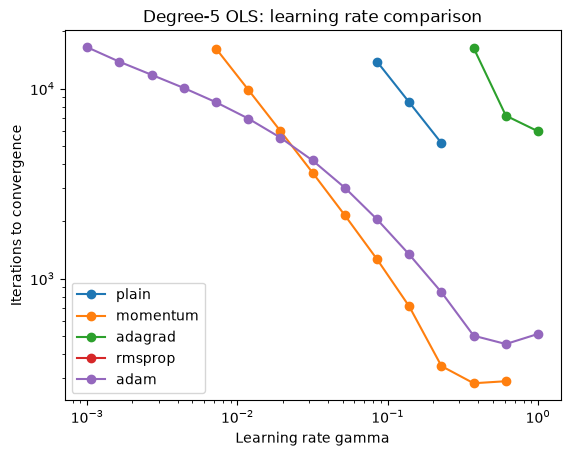


 plain
0.001 : did not converge
0.0016378937069540646 : did not converge
0.0026826957952797246 : did not converge
0.004393970560760791 : did not converge
0.0071968567300115215 : did not converge
0.011787686347935873 : did not converge
0.019306977288832496 : did not converge
0.03162277660168379 : did not converge
0.0517947467923121 : did not converge
0.08483428982440717 : 13862
0.13894954943731375 : 8461
0.22758459260747887 : 5163
0.3727593720314938 : did not converge
0.6105402296585326 : did not converge
1.0 : did not converge

 momentum
0.001 : did not converge
0.0016378937069540646 : did not converge
0.0026826957952797246 : did not converge
0.004393970560760791 : did not converge
0.0071968567300115215 : 16234
0.011787686347935873 : 9867
0.019306977288832496 : 5979
0.03162277660168379 : 3605
0.0517947467923121 : 2153
0.08483428982440717 : 1263
0.13894954943731375 : 713
0.22758459260747887 : 346
0.3727593720314938 : 281
0.6105402296585326 : 288
1.0 : did not converge

 adagrad
0.001 :

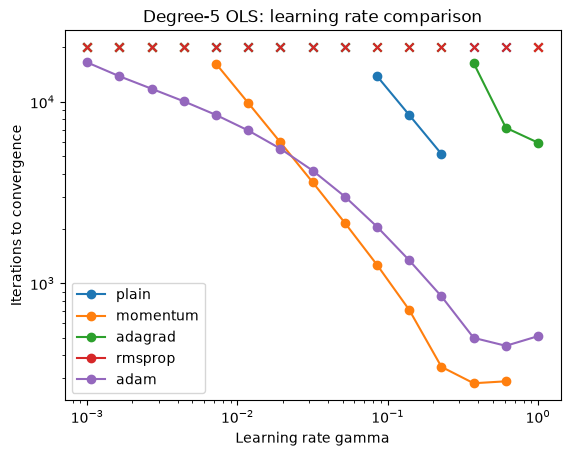

gamma = 0.01
plain 867
momentum 288
adagrad did not converge
rmsprop did not converge
adam 2606

gamma = 0.1
plain 80
momentum 222
adagrad 13553
rmsprop 129
adam 286

gamma = 0.5
plain 8
momentum 264
adagrad 632
rmsprop 13
adam 245



In [6]:
#Exercise 3

#Use the samme degree 5 OLS data

X = X5
y = y5 

#Closed form 
thetha_hat= closed_form(X,y,lam= 0.0)

#Gradient
grad_5_OLS = lambda theta: gradient(theta,X,y,lam=0)


theta0 = np.zeros(X.shape[1])
print("X shape",X.shape)
print("theta0 shape:", theta0.shape)


#Construct the mesh point, (Logspace)
gammas = np.logspace(-3, 0, 15)


#Apply the methods 
methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]
results = {method : [] for method in methods}


for method in methods:
    for gamma in gammas:
        history, _ = optimise( grad_5_OLS, theta0, method=method, gamma=gamma, num_iters=20000 )
        iterations = iterations_to_target( history, thetha_hat, tol=1e-6 )
        if iterations is None:
            results[method].append(np.nan)
        else:
            results[method].append(iterations)

plt.figure()

for method in methods:
    plt.plot(gammas,results[method],marker="o",label=method)


plt.xscale("log")
plt.yscale("log")
plt.xlabel("Learning rate gamma")
plt.ylabel("Iterations to convergence")
plt.title("Degree-5 OLS: learning rate comparison")
plt.legend()
plt.show()

for method in methods:
    print("\n", method)
    for gamma, iterations in zip(gammas, results[method]):
        if np.isnan(iterations):
            print(gamma, ": did not converge")
        else:
            print(gamma, ":", int(iterations))


#Exercise 3b

n = len(y)
H = (2/n) * X.T @ X
eigenvalues = np.linalg.eigvalsh(H)
lambda_max = np.max(eigenvalues)
gamma_plain_limit = 2 / lambda_max
beta = 0.9
gamma_momentum_limit = 2 * (1 + beta) / lambda_max
print("Exercise 3b")
print("lambda_max =", lambda_max)
print("Plain limit =", gamma_plain_limit)
print("Momentum limit =", gamma_momentum_limit)

plt.figure()

for method in methods:
    values = np.array(results[method], dtype=float)
    # Converged points
    mask = ~np.isnan(values)
    plt.plot(gammas[mask],values[mask],marker="o",label=method)
    # Did not converge
    failed = np.isnan(values)
    plt.scatter( gammas[failed], np.full(np.sum(failed), 20000), marker="x" )
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Learning rate gamma")
plt.ylabel("Iterations to convergence")
plt.title("Degree-5 OLS: learning rate comparison")
plt.legend()
plt.show()
#Conclusion
#Adam has the widest usable learning-rate range




#Exercise 3c

#We consider different gamma value

#Exercise 3c

gamma_value_3C = [0.01,0.1,0.5]
methods = ["plain","momentum","adagrad","rmsprop","adam"]

grad_OLS_2 = lambda theta: gradient(theta,X2,y2,lam=0.0)
theta0_2 = np.zeros(X2.shape[1])
theta_hat_2 = closed_form(X2,y2,lam=0.0)

for gamma in gamma_value_3C:
    print("gamma =",gamma)
    for method in methods:
        history,_ = optimise(grad_OLS_2,theta0_2,method=method,gamma=gamma,num_iters=20000,tol=0)
        iterations = iterations_to_target(history,theta_hat_2,tol=1e-6)
        print(method,iterations if iterations is not None else "did not converge")
    print()

#Conclusion
#For gamma=0.01, momentum is best.
#For gamma=0.1, plain gradient descent is best.
#For gamma=0.5, plain gradient descent is best.
#The ranking changes with gamma, so each optimiser should be tuned separately before comparison.

## Exercise 4: stochastic gradient descent

Replace the full gradient by a minibatch gradient, Eq. (4.33), inside an
epoch loop. Reshuffle the data every epoch and split the shuffled indices into
minibatches of size $M$; the update of Eq. (4.34) is one call to your
`optimiser_step`, so every optimiser of exercise 2 works with minibatches
unchanged.

In [7]:
def make_batches(n, batch_size, rng):
    """Shuffle the indices and split them into minibatches."""
    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]

def step_length(t, t0, t1):
    """The schedule of Eq. (4.40)."""
    return  t0 / (t + t1)
t = 0

def sgd(X, y, method="plain", n_epochs=50, batch_size=5, gamma=0.1, schedule=None, lam=0.0, seed=2026, **kw):
    """Minibatch SGD, Eq. (4.34), with any optimiser. schedule=(t0, t1) replaces gamma by Eq. (4.40).
    Returns the iterate after every epoch."""
    rng = np.random.default_rng(seed)
    n, p = X.shape
    theta, state, t = np.zeros(p), {}, 0
    history = [theta.copy()]
    for epoch in range(n_epochs):
        for batch in make_batches(n, batch_size, rng):

            t += 1
            X_batch = X[batch]
            y_batch = y[batch]
            g = ( 2 / len(batch) * X_batch.T @ (X_batch @ theta - y_batch) + 2 * lam * theta )                               
            gamma_t = gamma if schedule is None else step_length(t - 1, *schedule)          
            theta, state = optimiser_step(method, theta, g, state, t, gamma_t, **kw)
        history.append(theta.copy())
    return np.array(history)

### 4a)

At a fixed point $\boldsymbol{\theta} = (0, 3)$ of the degree-2 problem,
compute the gradient on many random minibatches of size $M = 1, 5, 25$ and
compare their mean and their spread (standard deviation over batches) with the
full gradient. Verify numerically that the spread falls as $1/\sqrt{M}$, and say
in one sentence what this means for the trade-off between batch size and cost
per step.

### 4b)

Run plain SGD with $M = 5$ on the degree-2 data for 100 epochs at
$\gamma = 0.1$ and at $\gamma = 0.02$, and plot the distance to the closed-form
solution against the number of *single-point gradient evaluations* (epochs
times $n$) together with full-batch gradient descent at $\gamma = 0.5$. Which
method is ahead early, which is ahead late, and does SGD with a constant
learning rate converge at all? Relate the size of the plateau to $\gamma$.

### 4c)

Now the schedule of Eq. (4.40). With $(t_0, t_1) = (1, 10)$ the initial
learning rate is $0.1$. Add this run to the plot of 4b). Then move to the
degree-5 data and run the same schedule: what happens? Find a pair $(t_0, t_1)$
with the same initial learning rate that works there, and explain your choice
in terms of the Robbins–Monro conditions $\sum_t \gamma_t = \infty$,
$\sum_t \gamma_t^2 < \infty$.

### 4d)

Study the batch size on the degree-5 data at $\gamma = 0.1$: $M \in \{1, 5, 20, 100\}$
for 100 epochs. One of these runs diverges although $\gamma$ is below
$2/\lambda_{\max}$ of the full Hessian. Which Hessian is relevant for a single
minibatch step, and what is its largest eigenvalue for $M = 1$? (For a single
point it is $2\|\boldsymbol{x}_i\|^2$.)

### 4e)

Combine SGD with Adam on the degree-5 data ($M = 5$, $\gamma \in \{0.01, 0.05\}$,
100 epochs) and compare with plain SGD and with momentum. Which combination
comes closest to the closed-form solution, and which one fails? This is the
setting of Project 1, part h).

M = 1
Std = [8.92991762 8.60182175]
1/sqrt(M) = 1.0
Mean = [ 1.53892843 -5.77434117]
Full gradient = [ 1.47833066 -5.45421202]
M = 5
Std = [3.88727208 3.73915169]
1/sqrt(M) = 0.4472135954999579
Mean = [ 1.65046818 -5.57287335]
Full gradient = [ 1.47833066 -5.45421202]
M = 25
Std = [1.53415662 1.50915731]
1/sqrt(M) = 0.2
Mean = [ 1.50441966 -5.44182584]
Full gradient = [ 1.47833066 -5.45421202]


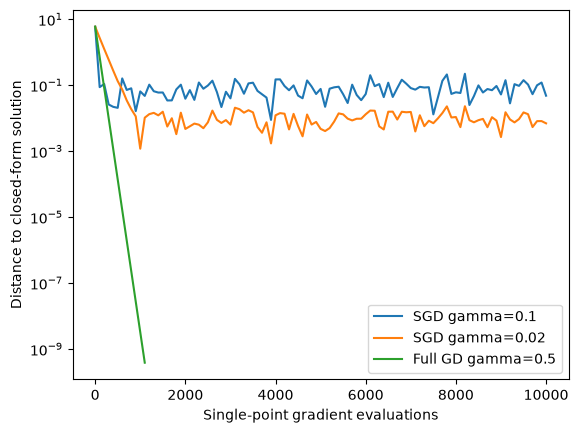

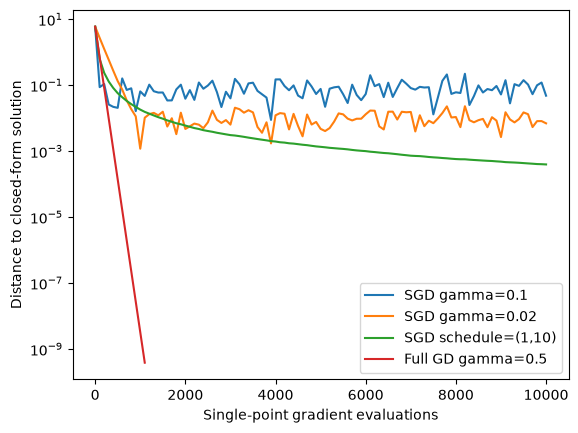

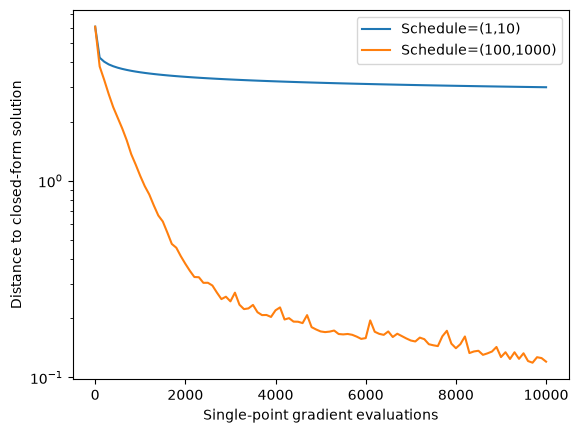

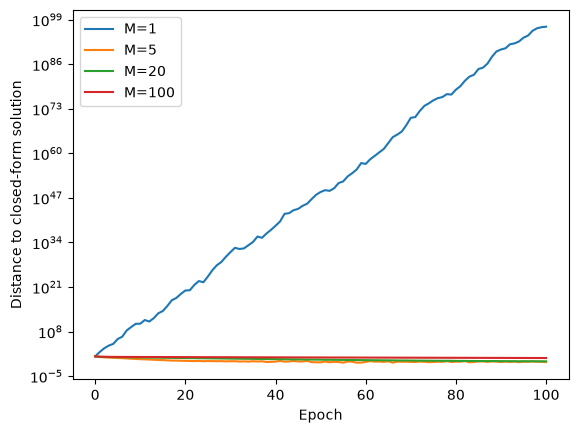

Largest eigenvalue for M=1 = 85.70382746421875
Stability limit = 0.023336180648816388
plain gamma= 0.01 final distance 0.9570298588899827
plain gamma= 0.05 final distance 0.1245481747414521
momentum gamma= 0.01 final distance 0.07920236710876444
momentum gamma= 0.05 final distance 3.4899482120444998e+19
adam gamma= 0.01 final distance 2.871701763573234
adam gamma= 0.05 final distance 0.14443333451519832


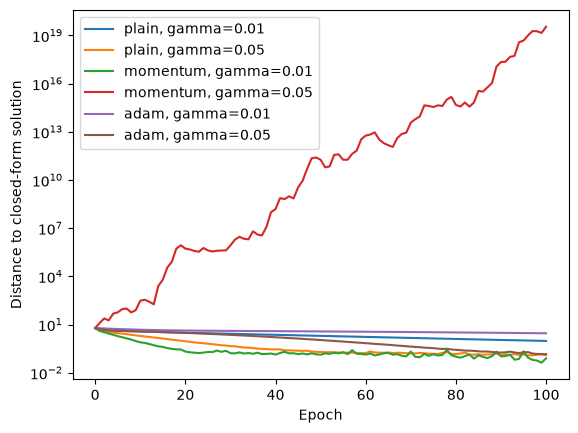

In [ ]:
#Exercise 4

# Exercise 4a

theta_SGD = np.array([0.0, 3.0])

M_values = [1, 5, 25]

n_trials = 1000

rng = np.random.default_rng(2026)

full_gradient = gradient(theta_SGD, X2, y2)


for M in M_values:

    gradients = []

    for trial in range(n_trials):

        indices = rng.choice( len(y2), size=M, replace=False )

        X_batch = X2[indices]
        y_batch = y2[indices]

        g = gradient( theta_SGD, X_batch, y_batch )

        gradients.append(g)
    gradients = np.array(gradients)
    mean_gradient = np.mean(gradients, axis=0)
    std_gradient = np.std(gradients, axis=0)
    print("M =", M)
    print("Std =", std_gradient)
    print("1/sqrt(M) =", 1 / np.sqrt(M))
    print("Mean =", mean_gradient)
    print("Full gradient =", full_gradient)

#Conclusion

#The minibatch gradients are close to the full gradient,
#Showing that the minibatch gradient is an approximately unbiased estimate of the full gradient.

#The standard deviation decreases as the batch size increases,
#Larger minibatches therefore give more stable gradient estimates, 
#but require more computation per optimisation step.

# Exercise 4b

n_epochs = 100
batch_size = 5
n = len(y2)

theta_hat = closed_form(X2, y2, lam=0.0)
theta0 = np.zeros(X2.shape[1])

# SGD
history_SGD_01 = sgd(X2, y2, method="plain", n_epochs=n_epochs, batch_size=batch_size, gamma=0.1)
history_SGD_002 = sgd(X2, y2, method="plain", n_epochs=n_epochs, batch_size=batch_size, gamma=0.02)

# Distance to closed-form solution
distance_SGD_01 = np.linalg.norm(history_SGD_01 - theta_hat, axis=1)
distance_SGD_002 = np.linalg.norm(history_SGD_002 - theta_hat, axis=1)

# Number of single-point gradient evaluations
x_SGD = np.arange(len(history_SGD_01)) * n

# Full-batch GD
grad_full = lambda theta: gradient(theta, X2, y2, lam=0.0)
history_GD, steps_GD = optimise(grad_full, theta0, method="plain", gamma=0.5)

distance_GD = np.linalg.norm(history_GD - theta_hat, axis=1)
x_GD = np.arange(len(history_GD)) * n

# Plot
plt.plot(x_SGD, distance_SGD_01, label="SGD gamma=0.1")
plt.plot(x_SGD, distance_SGD_002, label="SGD gamma=0.02")
plt.plot(x_GD, distance_GD, label="Full GD gamma=0.5")

plt.xlabel("Single-point gradient evaluations")
plt.ylabel("Distance to closed-form solution")
plt.yscale("log")
plt.legend()
plt.show()

# SGD is faster at the beginning, but with a constant learning rate it does not converge exactly and instead fluctuates around the optimum. A smaller learning rate gives a lower plateau.

# Exercise 4c

# Degree 2
history_schedule_2 = sgd(X2, y2, method="plain", n_epochs=100, batch_size=5, schedule=(1,10))
distance_schedule_2 = np.linalg.norm(history_schedule_2 - theta_hat, axis=1)

# Add schedule to the plot from Exercise 4b
plt.plot(x_SGD, distance_SGD_01, label="SGD gamma=0.1")
plt.plot(x_SGD, distance_SGD_002, label="SGD gamma=0.02")
plt.plot(x_SGD, distance_schedule_2, label="SGD schedule=(1,10)")
plt.plot(x_GD, distance_GD, label="Full GD gamma=0.5")
plt.xlabel("Single-point gradient evaluations")
plt.ylabel("Distance to closed-form solution")
plt.yscale("log")
plt.legend()
plt.show()


# Degree 5
theta_hat_5 = closed_form(X5, y5, lam=0.0)

history_schedule_5 = sgd(X5, y5, method="plain", n_epochs=100, batch_size=5, schedule=(1,10))
distance_schedule_5 = np.linalg.norm(history_schedule_5 - theta_hat_5, axis=1)

x_SGD_5 = np.arange(len(history_schedule_5)) * len(y5)

# Slower decay, same initial learning rate 0.1
history_schedule_5_good = sgd(X5, y5, method="plain", n_epochs=100, batch_size=5, schedule=(100,1000))
distance_schedule_5_good = np.linalg.norm(history_schedule_5_good - theta_hat_5, axis=1)

plt.plot(x_SGD_5, distance_schedule_5, label="Schedule=(1,10)")
plt.plot(x_SGD_5, distance_schedule_5_good, label="Schedule=(100,1000)")
plt.xlabel("Single-point gradient evaluations")
plt.ylabel("Distance to closed-form solution")
plt.yscale("log")
plt.legend()
plt.show()

#The decaying learning rate improves convergence, and a slower decay works better for the degree-5 problem.
#Both schedules satisfy the Robbins-Monro conditions,
# but (100,1000) decays more slowly and therefore makes better progress on the ill-conditioned degree-5 problem.

#Exercise 4d 

M_values_4D = [1,5,20,100]

theta_hat_5 = closed_form(X5,y5,lam=0.0)

for M in M_values_4D:
    history = sgd(X5,y5, method="plain",n_epochs= 100,batch_size= M, gamma=0.1)
    distance = np.linalg.norm(history-theta_hat_5,axis=1)
    plt.plot(distance, label="M=" + str(M))
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Distance to closed-form solution")
plt.legend()
plt.show()
lambda_max_M1 = np.max(2 * np.sum(X5**2, axis=1))

print("Largest eigenvalue for M=1 =", lambda_max_M1)
print("Stability limit =", 2 / lambda_max_M1)

#Conclusion

#M=1 diverges because the minibatch Hessian has a much larger maximum eigenvalue,
#so gamma=0.1 is too large for a single-point update.


#Exercise 4e

M_values_4E = 5

method_4E = ["plain","momentum","adam"]
gammas_4E = [0.01,0.05]


theta_hat_5 = closed_form(X5,y5,lam=0.0)

for method in method_4E:
    for gamma in gammas_4E:
        history = sgd(X5,y5,method = method,n_epochs=100,batch_size=M_values_4E, gamma=gamma)
        distance = np.linalg.norm(history-theta_hat_5,axis = 1)
        print(method,"gamma=", gamma,"final distance", distance[-1])
        plt.plot(distance, label=method + ", gamma=" + str(gamma))

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Distance to closed-form solution")
plt.legend()
plt.show()

#Conclusion

#Momentum with gamma=0.01 comes closest to the closed-form solution, while momentum with gamma=0.05 diverges.


## Exercise 5: the Runge function at degree 10 (Project 1, parts f and h)

Last week nothing converged on the Runge function $f(x) = 1/(1+25x^2)$ on
$[-1, 1]$ ($n = 100$, noise $0.1$) with a degree-10 polynomial:
$\kappa \approx 2 \times 10^6$. Use the Tuesday session's `runge_data` (the same
standardisation as above).

### 5a)

Run momentum and Adam with the full gradient for 30 000 iterations and plot
the excess cost $C(\boldsymbol{\theta}_k) - C(\hat{\boldsymbol{\theta}}_{\mathrm{OLS}})$
against the iteration. What accuracy do they reach, and does either of them
resolve the flat directions? Explain, with the rotated bowl of the Tuesday
session in mind, why a diagonal rescaling cannot fix a problem whose
ill-conditioning comes from strongly correlated columns.

### 5b)

Add Ridge with $\lambda \in \{10^{-3}, 10^{-2}\}$: what are the condition
numbers now, and how many iterations do momentum and Adam need to reach an
excess cost of $10^{-8}$? Compare the Ridge coefficients with the OLS ones and
discuss whether Ridge is "cheating" — what problem has it solved, and is that
the problem you wanted solved? (Part i) of Project 1 answers the last question
with cross-validation.)

### 5c)

Take one Newton step from $\boldsymbol{\theta}_0 = \boldsymbol{0}$ with the exact
Hessian $\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}$ — or, following week 37, with
`jax.hessian` of your cost — and compare with the closed form. What did Newton
use that none of the first-order methods had, and why can we not simply do
this for a neural network?

### 5d)

Finally, minibatches: run SGD with Adam ($M = 10$, a decaying schedule of
your choice, 500 epochs) on the degree-10 problem and compare the excess cost
per gradient evaluation with the full-gradient Adam run of 5a). Give a
critical assessment, in the spirit of part h) of Project 1: what has the noise
bought, and what has it cost?

kappa = 1985624.4823899716


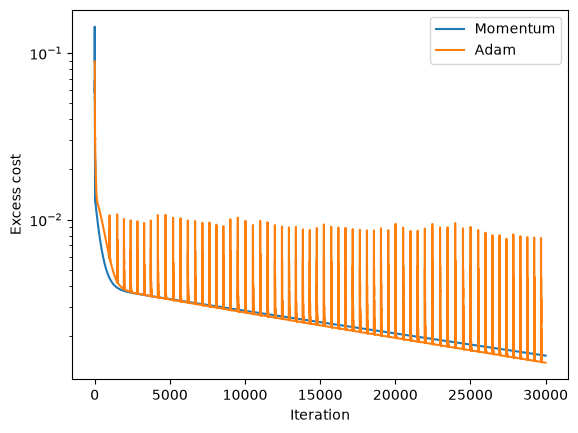

Final Momentum excess cost = 0.0015250993608444136
Final Adam excess cost = 0.0013836563744600693
Best Momentum excess cost = 0.0015250993608444136
Best Adam excess cost = 0.0013836563744600693
Exercises 5a
lambda = 0.001
Momentum iterations = 670
Adam iterations = 1207
OLS coefficients = [-1.14559889e-01 -3.09075629e+00  4.32584127e-01  1.34078708e+01
 -6.37735763e-01 -2.65268432e+01  3.10990229e-01  2.43549480e+01
  6.32484027e-05 -8.40479698e+00]
Ridge coefficients = [-0.06071295 -1.08311798  0.13979829  1.33081575 -0.14043121 -0.07641436
 -0.05595847 -0.40018984  0.10297192 -0.00309303]
lambda = 0.01
Momentum iterations = 141
Adam iterations = 250
OLS coefficients = [-1.14559889e-01 -3.09075629e+00  4.32584127e-01  1.34078708e+01
 -6.37735763e-01 -2.65268432e+01  3.10990229e-01  2.43549480e+01
  6.32484027e-05 -8.40479698e+00]
Ridge coefficients = [-0.02931024 -0.64140894  0.03370043  0.36142026 -0.00871682  0.22613745
 -0.00608585  0.00774866  0.01395914 -0.1633084 ]
lambda = 0.00

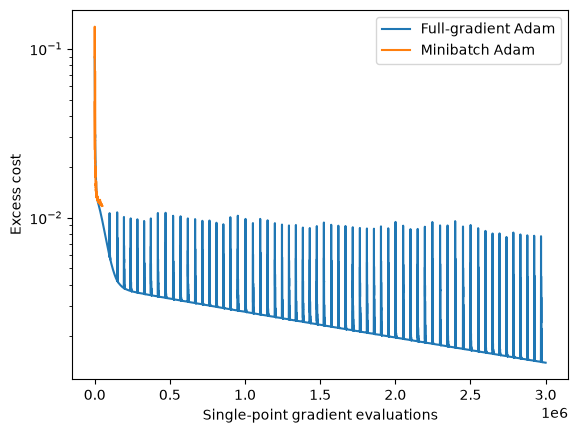

Exercises 5d


In [ ]:

#Define the Rungefunction

def Runge_function(x):
    return 1/(1+25*x**2)


# Exercise5

def Runge_function(x):
    return 1 / (1 + 25 * x**2)

def runge_data(n=100, degree=10, noise=0.1, seed=2026):
    rng = np.random.default_rng(seed)
    x = rng.uniform(-1.0, 1.0, n)
    y = Runge_function(x) + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    return X_norm, y - y.mean()

X10, y10 = runge_data()

eigs10 = hessian_eigs(X10)
print("kappa =", eigs10.max() / eigs10.min())


#Exercise 5a
itetations_value = 30000

theta_OLS_RG_10 = closed_form(X10,y10,lam=0.0)
thetha_10 = np.zeros(X10.shape[1])

grad_OLS_RG_10 = lambda theta: gradient(theta,X10,y10,lam=0.0)

cost_OLS_RG_10=cost(theta_OLS_RG_10,X10,y10,lam=0.0)


gamma_momentum = 0.3
gamma_adam = 0.05

history_momentum_10, _ = optimise(grad_OLS_RG_10, thetha_10, method="momentum", gamma=gamma_momentum, num_iters=itetations_value, tol=0)

history_adam_10, _ = optimise(grad_OLS_RG_10, thetha_10, method="adam", gamma=gamma_adam, num_iters=itetations_value, tol=0)
excess_momentum = np.array([cost(theta, X10, y10) - cost_OLS_RG_10 for theta in history_momentum_10])

excess_adam = np.array([cost(theta, X10, y10) - cost_OLS_RG_10 for theta in history_adam_10])

plt.plot(excess_momentum, label="Momentum")
plt.plot(excess_adam, label="Adam")
plt.xlabel("Iteration")
plt.ylabel("Excess cost")
plt.yscale("log")
plt.legend()
plt.show()
print("Final Momentum excess cost =", excess_momentum[-1])
print("Final Adam excess cost =", excess_adam[-1])

print("Best Momentum excess cost =", np.min(excess_momentum))
print("Best Adam excess cost =", np.min(excess_adam))
print("Exercises 5a")
#Momentum and Adam still struggle because the problem is strongly ill-conditioned.
#Exercises 5b

lambdas_5b= [1e-3,1e-2]

for lam in lambdas_5b:

    theta_Ridge = closed_form(X10, y10, lam=lam)

    grad_Ridge = lambda theta, lam=lam: gradient(theta, X10, y10, lam=lam)

    cost_Ridge = cost(theta_Ridge, X10, y10, lam=lam)

    eigs = hessian_eigs(X10, lam=lam)

    gamma_momentum_Ridge = 0.9 * 2 * (1 + 0.9) / eigs.max()

    theta0_Ridge = np.zeros(X10.shape[1])
    history_momentum_Ridge, _ = optimise(grad_Ridge, theta0_Ridge, method="momentum", gamma=gamma_momentum_Ridge, num_iters=30000, tol=0)
    history_adam_Ridge, _ = optimise(grad_Ridge, theta0_Ridge, method="adam", gamma=0.05, num_iters=30000, tol=0)
    excess_momentum_Ridge = np.array([cost(theta, X10, y10, lam=lam) - cost_Ridge for theta in history_momentum_Ridge])

    excess_adam_Ridge = np.array([cost(theta, X10, y10, lam=lam) - cost_Ridge for theta in history_adam_Ridge])

    momentum_indices = np.where(excess_momentum_Ridge < 1e-8)[0]
    adam_indices = np.where(excess_adam_Ridge < 1e-8)[0]

    momentum_iterations = momentum_indices[0] if len(momentum_indices) > 0 else None
    adam_iterations = adam_indices[0] if len(adam_indices) > 0 else None

    print("lambda =", lam)
    print("Momentum iterations =", momentum_iterations)
    print("Adam iterations =", adam_iterations)
    print("OLS coefficients =", theta_OLS_RG_10)
    print("Ridge coefficients =", theta_Ridge)
for lam in lambdas_5b:
    eigs = hessian_eigs(X10, lam=lam)
    kappa = eigs.max() / eigs.min()
    print("lambda =", lam, "kappa =", kappa)
print("Exercises 5b")
#Ridge improves the condition number but changes the original OLS problem.
#Exercise 5c
n = len(y10)

H = (2 / n) * X10.T @ X10

theta0_newton = np.zeros(X10.shape[1])

g0 = gradient(theta0_newton, X10, y10)
theta_newton = theta0_newton - np.linalg.solve(H, g0)
print("Newton =", theta_newton)
print("Closed form =", theta_OLS_RG_10)
print("Difference =", np.linalg.norm(theta_newton - theta_OLS_RG_10))
print("Exercises 5c")
#Newton uses the full Hessian, but this is too expensive
#Exercise 5d
schedule_adam = (10, 100)

history_SGD_adam_10 = sgd(X10, y10, method="adam", n_epochs=500, batch_size=10, schedule=schedule_adam)

excess_SGD_adam = np.array([cost(theta, X10, y10) - cost_OLS_RG_10 for theta in history_SGD_adam_10])
x_SGD_adam = np.arange(len(history_SGD_adam_10)) * len(y10)
x_full_adam = np.arange(len(history_adam_10)) * len(y10)

plt.plot(x_full_adam, excess_adam, label="Full-gradient Adam")
plt.plot(x_SGD_adam, excess_SGD_adam, label="Minibatch Adam")
plt.xlabel("Single-point gradient evaluations")
plt.ylabel("Excess cost")
plt.yscale("log")
plt.legend()
plt.show()
print("Exercises 5d")

## Insights you should have gained this week — a self-check

Before you hand in, go through the list below without looking at the notes.
Each row is a question we may ask in the Tuesday session or on Project 1; the
right-hand column is the insight it tests, in one sentence.

| Ask yourself | The insight it tests |
|---|---|
| Adam converged for every learning rate from $10^{-3}$ to $1$ and plain gradient descent only in a narrow window. Does $\gamma$ not matter for Adam? | It matters for speed, not for stability: the adaptive step is at most $\gamma$ per coordinate (division by $\sqrt{\hat v}$), so $\gamma$ is a *length in parameter space* and cannot violate Eq. (4.20) — but the best $\gamma$ was still several times faster than the worst. |
| RMSProp at a constant $\gamma$ never reached $10^{-6}$ on a convex quadratic. Why? | Near the minimum $r \approx g^2$ and the step is $\approx \gamma\,\mathrm{sign}(g)$, a fixed length that cannot shrink: the iterate rattles at radius $\sim\gamma$. It needs a decaying $\gamma$ (Eq. 4.40), or the first moment — which is Adam. |
| AdaGrad was slower than plain gradient descent on the degree-6 Runge problem. Is it broken? | No: $\boldsymbol{r}_t$ never forgets, Eq. (4.42), so the effective learning rate decays like $1/\sqrt t$ whether or not the minimum is near. That is the wrong behaviour on a smooth convex problem and the right one for sparse features, which it was designed for. |
| Why does Adam divide its moments by $1 - \beta_i^t$? | Both averages start from zero, so $\mathbb{E}[v_t] = (1-\beta_2^t)\,\mathbb{E}[g^2]$, Eq. (4.53): at $t=1$ the raw second moment is a thousand times too small and the step would be $\sqrt{1000}/\sqrt{10}\approx 3$ times too long. Dividing by the known factor removes the bias exactly; for large $t$ the correction vanishes. |
| What does "adaptive" mean, in one sentence? | Each coordinate gets its own step $\gamma/\sqrt{v_j}$, with $v_j$ the recent mean square gradient as a proxy for the curvature $\lambda_j$: a diagonal, $\mathcal{O}(p)$ imitation of Newton's $\boldsymbol{H}^{-1/2}$ (Section 4.8). |
| Rotating the bowl by $45^\circ$ left plain gradient descent unchanged and made AdaGrad and RMSProp fail. Why? | Eq. (4.19) depends on the eigenvalues only, which a rotation preserves; the adaptive methods rescale *coordinates* and see only the diagonal of $\boldsymbol{H}$. A valley that is not axis-aligned — a correlated polynomial basis, for instance — has its curvature off the diagonal. |
| Every first-order method stalled at an excess cost of $10^{-3}$ on the degree-10 Runge problem, and one Newton step solved it. What did Newton have? | The full Hessian, off-diagonal entries included: $\kappa = 2\times10^6$ is invisible to it, Eq. (4.8). We cannot afford it for a network ($\mathcal{O}(p^3)$); every method from momentum to Adam is a cheaper approximation to it. |
| Book Table 4.1: no optimiser is best at the same $\gamma$ as any other. What does that mean for comparing methods? | A learning rate is not comparable across optimisers — plain descent multiplies the gradient by $\gamma$, the adaptive methods normalise it first. Compare methods at each one's *best* $\gamma$, found by a scan, never at one shared value. |
| Plain SGD with $M=5$ sat at a distance $5\times10^{-2}$ from the minimum for ninety epochs. Has it converged? | No, it has equilibrated: the minibatch gradient is an unbiased estimate with noise $\propto 1/\sqrt M$ (Section 2.5), and at constant $\gamma$ the iterate is a random walk in a cloud of radius $\propto\sqrt\gamma/\sqrt M$. A longer run does not help; a smaller $\gamma$, a larger $M$ or a decaying $\gamma_t$ does. |
| Full-batch gradient descent beat SGD per gradient evaluation on the degree-2 data. Is SGD overrated? | On a small benign problem the exact gradient is cheap and converges geometrically, Eq. (4.26). For $n = 10^6$ one full gradient costs $10^4$ minibatch steps: per unit of computation SGD is far ahead, and it never needs the whole data set in memory — which is why every framework is built on minibatches. |
| The schedule $(t_0,t_1)=(1,10)$ worked at degree 2 and froze at degree 5. Which condition did it break? | Robbins–Monro needs $\sum_t\gamma_t = \infty$; in a finite run $\gamma_t = t_0/(t+t_1)$ with a small $t_1$ decays so fast that the accumulated step cannot cross a $\kappa = 520$ valley. Keep $\gamma_0 = t_0/t_1$ and enlarge both, so the decay starts later. |
| SGD with $M=1$ diverged at a $\gamma$ below $2/\lambda_{\max}$ of the full Hessian. How? | A minibatch step sees the Hessian of the *minibatch* cost; for one point it is $2\boldsymbol{x}_i\boldsymbol{x}_i^T$ with eigenvalue $2\|\boldsymbol{x}_i\|^2$, far above the average. The full-batch bound is a bound on the average, not on every step. |
| When should I stop a stochastic run? | Not on the gradient: monitor the validation cost and stop when it rises while the training cost still falls (early stopping, Section 4.7.1) — a regularisation method as much as a termination rule. |


### Practicalities

Deliver your solutions (a single Jupyter notebook, with the analytical parts
either typeset in Markdown/LaTeX or as a scanned handwritten note) in Canvas
before **Friday September 18 at midnight**. Collaboration is encouraged — list
your collaborators.